## DSCI 552 Homework 2

**Name:** Rodrigo Garcia

**Github:** garciar8-port

**USC ID:** 2105066875

imports + plotting settings below. Installing from `requirements.txt` in the next cell.

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

SEED = 552
np.random.seed(SEED)

# one fixed color per role and float formatting
C_PTS = "#2a78d6"
C_FIT = "#eb6834"
C_ALT = "#1baf7a"
C_REF = "#898781"
def format_number(value):
    return f"{value:.4g}"

pd.set_option("display.float_format", format_number)

## 1. Combined Cycle Power Plant Data Set

### 1(a) - data

Loaded Sheet1 from `data/CCPP/Folds5x2_pp.xlsx`, following footnote 1. The 5 sheets are shuffled versions of the same 9,568 observations. PE in the file = EP in the assignment.

In [3]:
df = pd.read_excel("data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
predictors = ["AT", "V", "AP", "RH"]
response = "PE"
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024,73.17,463.3
1,25.18,62.96,1020,59.08,444.4
2,5.11,39.4,1012,92.14,488.6
3,20.86,57.32,1010,76.64,446.5
4,10.82,37.5,1009,96.62,473.9


### 1(b) Exploring the data

i.) rows and columns

In [4]:
print("shape (rows, cols):", df.shape)
missing_by_column = df.isnull().sum()
missing_count = missing_by_column.sum()
duplicate_count = df.duplicated().sum()
print("missing values:", int(missing_count))
print("exact duplicate rows:", int(duplicate_count))
df.dtypes

shape (rows, cols): (9568, 5)
missing values: 0
exact duplicate rows: 41


AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

9,568 hourly observations, collected at full load during 2006-2011. Four predictors + one response:

| column | meaning | units |
|---|---|---|
| AT | ambient temperature | °C |
| V | exhaust vacuum (steam turbine side) | cm Hg |
| AP | ambient pressure | mbar |
| RH | relative humidity | % |
| PE | net hourly electrical energy output (response) | MW |

All numeric, no missing values. There are 41 exact duplicate rows; keeping them since I don't know whether they're recording errors or repeated observations. Checking overlap between train/test in part (h).

ii.) Pairwise scatterplots of all 5 variables

Added a correlation heatmap too, easier to compare the strongest relationships.

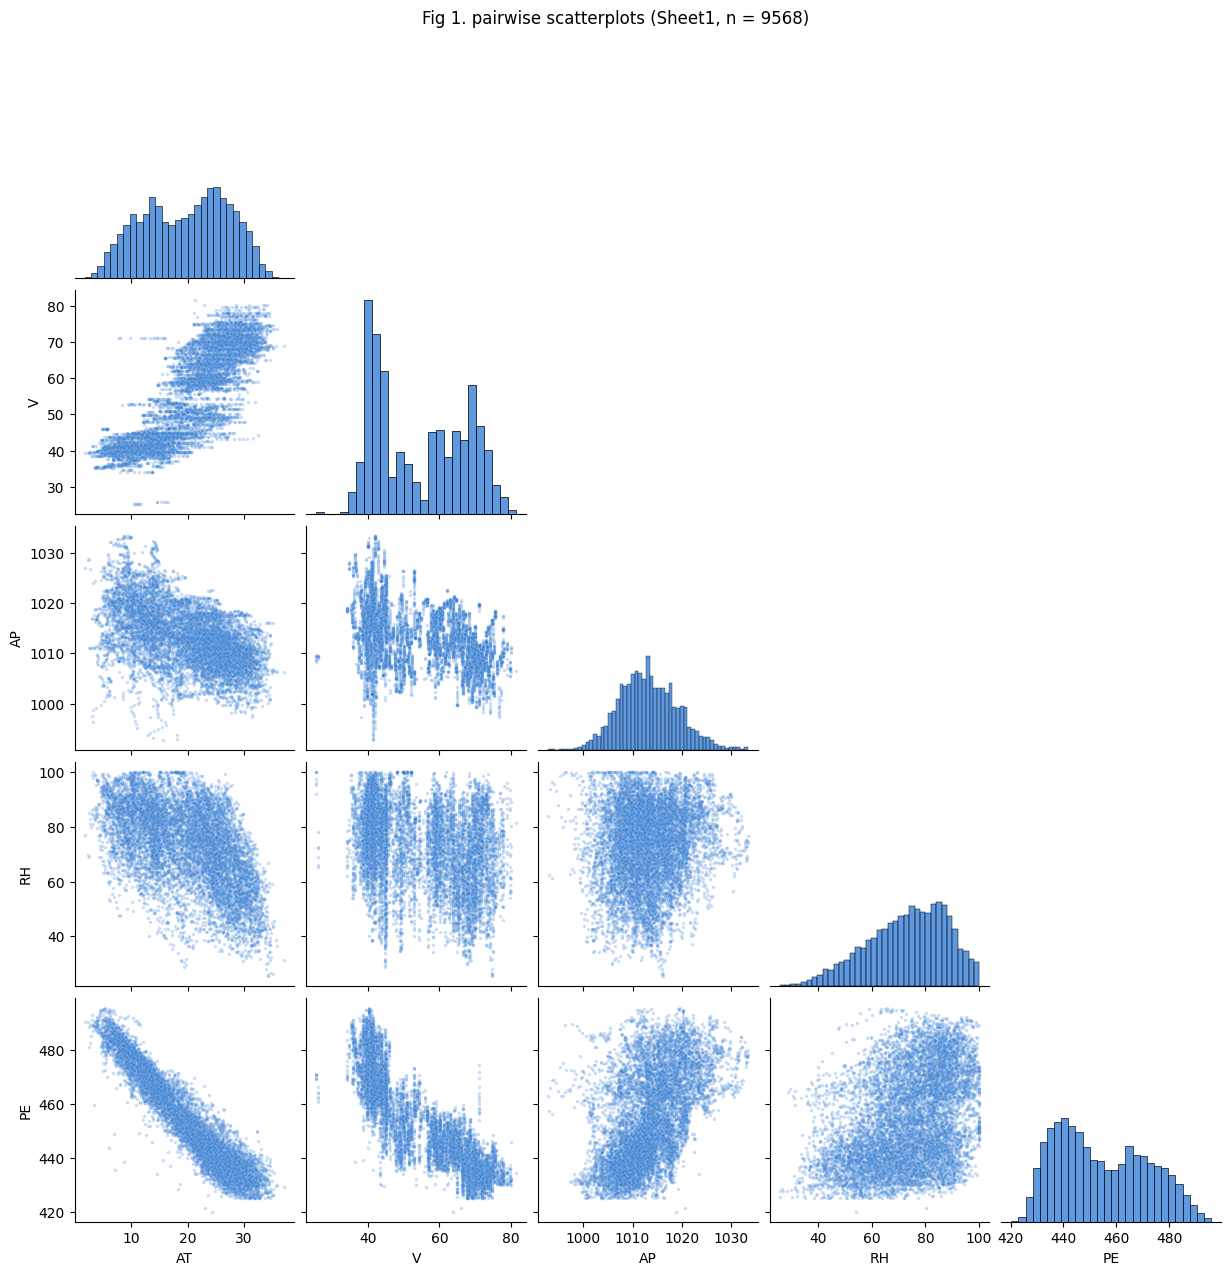

In [5]:
g = sns.pairplot(df, corner=True, plot_kws={"s": 6, "alpha": 0.25, "color": C_PTS},
                 diag_kws={"color": C_PTS})
g.figure.suptitle("Fig 1. pairwise scatterplots (Sheet1, n = 9568)", y=1.02)
plt.show()

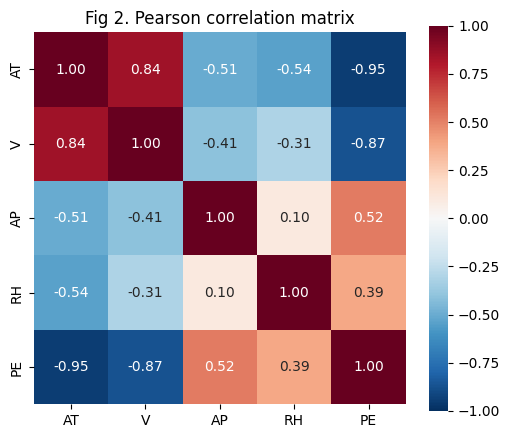

In [6]:
corr = df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Fig 2. Pearson correlation matrix")
plt.show()

AT has the clearest relationship with PE, strongly negative at r = -0.95. V is next at -0.87, but AT and V also move together (r = 0.84), so they're picking up some of the same information. AP + RH have weaker positive relationships with PE, at 0.52 and 0.39.

PE has two noticeable peaks, around 440 and 470 MW.

iii.) Summary table: mean, median, range, Q1, Q3, IQR (plus min/max/std for reference)

In [7]:
desc = df.describe().T
summary = pd.DataFrame({
    "mean": desc["mean"],
    "median": df.median(),
    "std": desc["std"],
    "min": desc["min"],
    "max": desc["max"],
    "range": desc["max"] - desc["min"],
    "Q1": desc["25%"],
    "Q3": desc["75%"],
    "IQR": desc["75%"] - desc["25%"],
})
summary.round(3)

,mean,median,std,min,max,range,Q1,Q3,IQR
AT,19.65,20.34,7.452,1.81,37.11,35.3,13.51,25.72,12.21
V,54.31,52.08,12.71,25.36,81.56,56.2,41.74,66.54,24.8
AP,1013,1013,5.939,992.9,1033,40.41,1009,1017,8.16
RH,73.31,74.97,14.6,25.56,100.2,74.6,63.33,84.83,21.5
PE,454.4,451.6,17.07,420.3,495.8,75.5,439.8,468.4,28.68


AP stays pretty close to 1013 mbar, while RH spreads further out on the low end. PE's mean is above its median, which fits the shape in the pairplot.

### 1(c) - Simple linear regression

Fit `PE ~ X` once per predictor. Testing each slope against 0 at α = 0.05, then comparing R² to see how much each predictor explains on its own (Lesson 2, PDF pp. 35–37).

In [8]:
simple_models = {}
rows = []

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df[response]
    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model

    row = {
        "intercept": model.params["const"],
        "slope": model.params[predictor],
        "std err": model.bse[predictor],
        "t": model.tvalues[predictor],
        "p-value": model.pvalues[predictor],
        "R^2": model.rsquared,
    }
    rows.append(row)

simple_tbl = pd.DataFrame(rows, index=predictors)
simple_tbl

,intercept,slope,std err,t,p-value,R^2
AT,497,-2.171,0.007443,-291.7,0,0.8989
V,517.8,-1.168,0.006776,-172.4,0,0.7565
AP,-1055,1.49,0.02513,59.3,0,0.2688
RH,421,0.4557,0.01101,41.4,0,0.1519


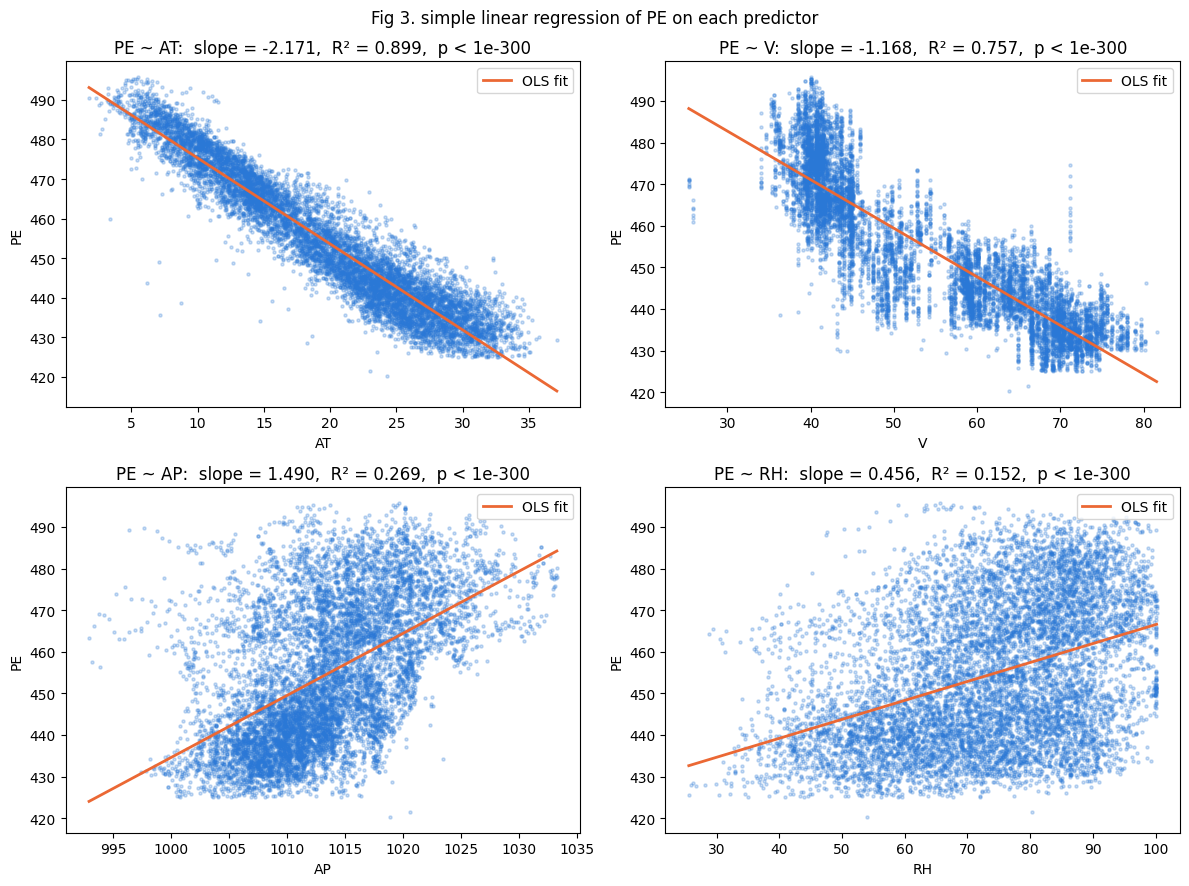

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i in range(len(predictors)):
    predictor = predictors[i]
    ax = axes[i]
    model = simple_models[predictor]

    x_values = np.linspace(df[predictor].min(), df[predictor].max(), 100)
    intercept = model.params["const"]
    slope = model.params[predictor]
    fitted_line = intercept + slope * x_values

    ax.scatter(df[predictor], df[response], s=5, alpha=0.25, color=C_PTS)
    ax.plot(x_values, fitted_line, color=C_FIT, lw=2, label="OLS fit")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")
    ax.legend(loc="upper right")

    p_value = model.pvalues[predictor]
    if p_value < 1e-300:
        p_text = "p < 1e-300"
    else:
        p_text = f"p = {p_value:.1e}"

    title = f"PE ~ {predictor}:  slope = {slope:.3f},  R² = {model.rsquared:.3f},  {p_text}"
    ax.set_title(title)

fig.suptitle("Fig 3. simple linear regression of PE on each predictor")
fig.tight_layout()
plt.show()

All four slopes are significant at α = 0.05, so I reject $H_0: \beta_1 = 0$ for each model. The p-values printed as 0 are too small for the calculation to represent.

AT gives the best fit, followed by V. AP + RH are significant too, but their R² values are much lower. A small p-value doesn't mean the predictor explains much of PE by itself.

For the outlier checks, I used AI tools + the statsmodels docs to explore studentized residuals and Cook's distance. These go beyond Lesson 2, which lists outliers and high-leverage points as topics not covered (PDF p. 117).

Studentized residuals scale the errors so unusually large ones stand out. Using the external version here, which estimates the error scale without the point being checked. Cook's distance measures how much a point affects the fitted model.

Flagging |studentized residual| > 3 and Cook's D > 4/n for a closer look.

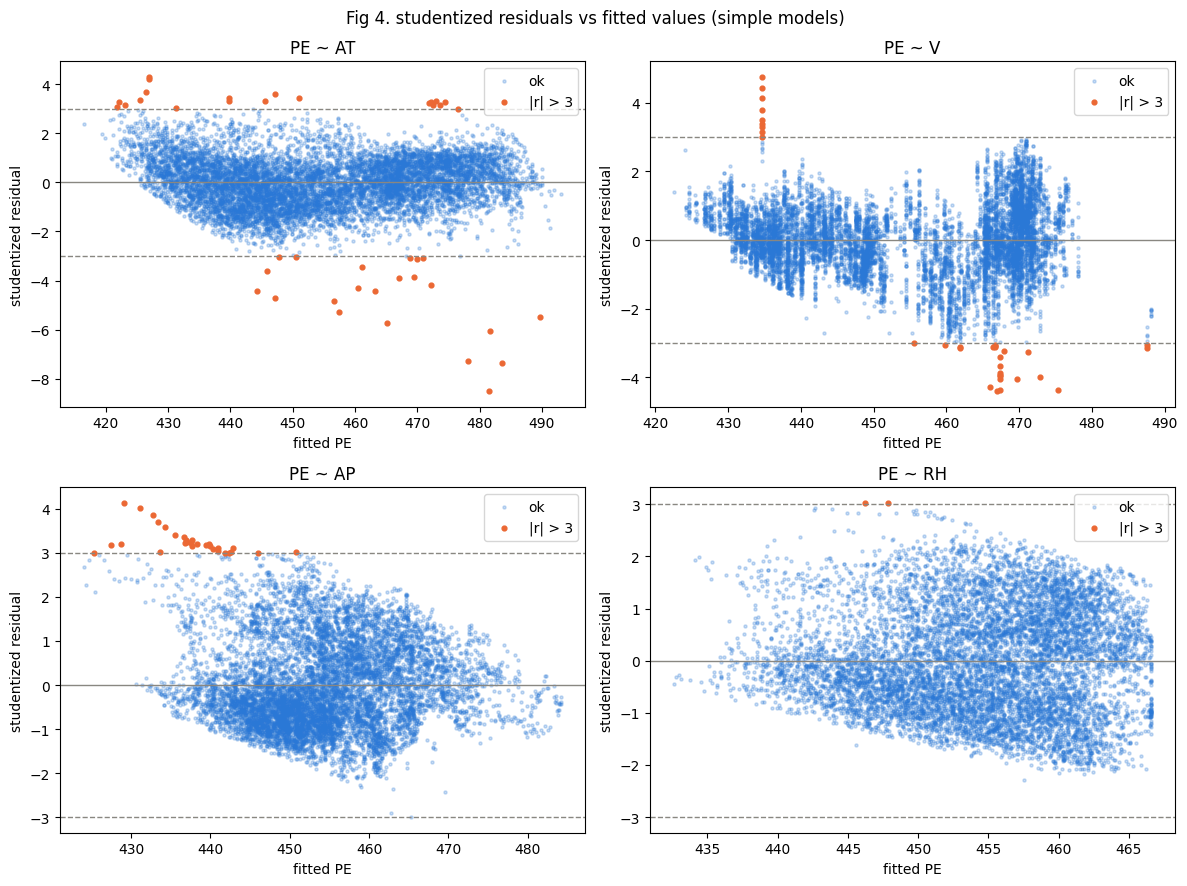

,|stud. resid| > 3,Cook's D > 4/n,max Cook's D,max |stud. resid|
AT,42,416,0.01432,8.502
V,33,423,0.003243,4.751
AP,30,300,0.008152,4.134
RH,2,249,0.002059,3.024


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
out_rows = []
cooks_threshold = 4 / len(df)

for i in range(len(predictors)):
    predictor = predictors[i]
    ax = axes[i]
    model = simple_models[predictor]
    influence = OLSInfluence(model)
    residuals = influence.resid_studentized_external
    cooks_distance = influence.cooks_distance[0]

    large_residual = np.abs(residuals) > 3
    other_residual = np.abs(residuals) <= 3
    large_cooks_distance = cooks_distance > cooks_threshold

    row = {
        "|stud. resid| > 3": int(large_residual.sum()),
        "Cook's D > 4/n": int(large_cooks_distance.sum()),
        "max Cook's D": cooks_distance.max(),
        "max |stud. resid|": np.abs(residuals).max(),
    }
    out_rows.append(row)

    fitted_values = model.fittedvalues
    ax.scatter(fitted_values[other_residual], residuals[other_residual],
               s=5, alpha=0.25, color=C_PTS, label="ok")
    ax.scatter(fitted_values[large_residual], residuals[large_residual],
               s=12, color=C_FIT, label="|r| > 3")
    ax.axhline(0, color=C_REF, lw=1)
    ax.axhline(3, color=C_REF, lw=1, ls="--")
    ax.axhline(-3, color=C_REF, lw=1, ls="--")
    ax.set_xlabel("fitted PE")
    ax.set_ylabel("studentized residual")
    ax.set_title(f"PE ~ {predictor}")
    ax.legend(loc="upper right")

fig.suptitle("Fig 4. studentized residuals vs fitted values (simple models)")
fig.tight_layout()
plt.show()
outlier_tbl = pd.DataFrame(out_rows, index=predictors)
outlier_tbl

The two checks flag different points. A point can have a big prediction error without moving the fitted line much. Keeping the flagged rows since there's no evidence they're recording errors.

### 1(d) - Multiple regression

Fit PE on all four predictors together. Each coefficient now accounts for the other three predictors.

In [11]:
X_all = sm.add_constant(df[predictors])
mlr = sm.OLS(df[response], X_all).fit()
print(mlr.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:57:33   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

R² goes up to 0.929, compared with about 0.90 for AT alone. The overall F-test is significant, and all four predictors have p < 0.001.

Holding the others fixed, a 1-unit increase in AT / V / AP / RH changes predicted PE by about -1.98 / -0.23 / +0.06 / -0.16 MW. Units are °C, cm Hg, mbar, and percentage points, respectively. These are relationships in this dataset, not evidence of cause and effect.

### 1(e) - Simple vs multiple regression coefficients

One point per predictor: x = simple regression slope from (c), y = multiple regression coefficient from (d).

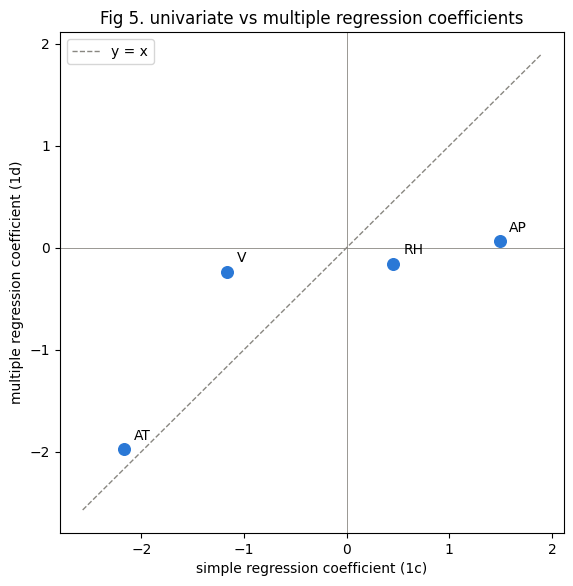

,simple (1c),multiple (1d)
AT,-2.171,-1.978
V,-1.168,-0.2339
AP,1.49,0.06208
RH,0.4557,-0.1581


In [12]:
simple_coefficients = []
multiple_coefficients = []

for predictor in predictors:
    simple_coefficients.append(simple_models[predictor].params[predictor])
    multiple_coefficients.append(mlr.params[predictor])

coef_cmp = pd.DataFrame({
    "simple (1c)": simple_coefficients,
    "multiple (1d)": multiple_coefficients,
}, index=predictors)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(coef_cmp["simple (1c)"], coef_cmp["multiple (1d)"], s=70, color=C_PTS, zorder=3)
for predictor in predictors:
    x_coordinate = coef_cmp.loc[predictor, "simple (1c)"]
    y_coordinate = coef_cmp.loc[predictor, "multiple (1d)"]
    plt.annotate(predictor, (x_coordinate, y_coordinate),
                 textcoords="offset points", xytext=(7, 7))
lo = min(coef_cmp.min().min(), 0) - 0.4
hi = max(coef_cmp.max().max(), 0) + 0.4
plt.plot([lo, hi], [lo, hi], ls="--", color=C_REF, lw=1, label="y = x")
plt.axhline(0, color=C_REF, lw=0.6)
plt.axvline(0, color=C_REF, lw=0.6)
plt.xlabel("simple regression coefficient (1c)")
plt.ylabel("multiple regression coefficient (1d)")
plt.title("Fig 5. univariate vs multiple regression coefficients")
plt.legend()
plt.show()
coef_cmp

AT's coefficient doesn't move much, V + AP shrink a lot, and RH actually flips from positive to negative.

The simple models only look at one predictor at a time. Once the others are included, the shared information gets accounted for too, which changes the coefficients. RH's positive relationship on its own doesn't carry over when AT, V, and AP are held fixed.

### 1(f) - Nonlinear association

Adding squared + cubed terms for each predictor so the fit can bend (Lesson 2, PDF p. 115).

Standardizing first: `z = (X - mean(X)) / sd(X)`, which keeps the powers manageable. The coefficients and individual p-values below are for z, z², and z³.

Joint F-test on the two added terms: H0: β2 = β3 = 0, at α = 0.05. This checks whether the squared + cubed terms together improve on the straight-line fit.

In [13]:
poly = PolynomialFeatures(degree=3, include_bias=False)
cubic_models = {}
rows = []

for predictor in predictors:
    predictor_mean = df[predictor].mean()
    predictor_sd = df[predictor].std()
    z = (df[predictor] - predictor_mean) / predictor_sd
    # PolynomialFeatures expects a two-dimensional input: one column here.
    z_column = z.to_numpy().reshape(-1, 1)
    powers = poly.fit_transform(z_column)
    squared_name = f"{predictor}^2"
    cubed_name = f"{predictor}^3"
    column_names = [predictor, squared_name, cubed_name]
    X_polynomial = pd.DataFrame(powers, columns=column_names)
    X_polynomial = sm.add_constant(X_polynomial)

    model = sm.OLS(df[response].values, X_polynomial).fit()
    cubic_models[predictor] = model

    # Coefficient order: intercept, z, z², z³.
    # These two rows test whether the z² and z³ coefficients are both zero.
    nonlinear_constraints = [[0, 0, 1, 0], [0, 0, 0, 1]]
    nonlinear_test = model.f_test(nonlinear_constraints)

    row = {
        "β1 (z)": model.params[predictor],
        "p(z)": model.pvalues[predictor],
        "β2 (z²)": model.params[squared_name],
        "p(z²)": model.pvalues[squared_name],
        "β3 (z³)": model.params[cubed_name],
        "p(z³)": model.pvalues[cubed_name],
        "R² linear": simple_models[predictor].rsquared,
        "R² cubic": model.rsquared,
        "p(nonlinear, joint F)": float(nonlinear_test.pvalue),
    }
    rows.append(row)

cubic_tbl = pd.DataFrame(rows, index=predictors)
cubic_tbl

,β1 (z),p(z),β2 (z²),p(z²),β3 (z³),p(z³),R² linear,R² cubic,"p(nonlinear, joint F)"
AT,-18.11,0,1.808,3.312e-231,1.107,3.652e-110,0.8989,0.9119,3.478e-285
V,-15.89,0,3.097,8.977e-131,0.2757,0.01373,0.7565,0.775,7.04e-165
AP,11.67,0,1.56,2.193e-46,-1.045,2.123e-67,0.2688,0.2975,4.209e-84
RH,7.741,9.649e-152,-0.2825,0.1014,-0.4737,1.44e-05,0.1519,0.1537,3.8e-05


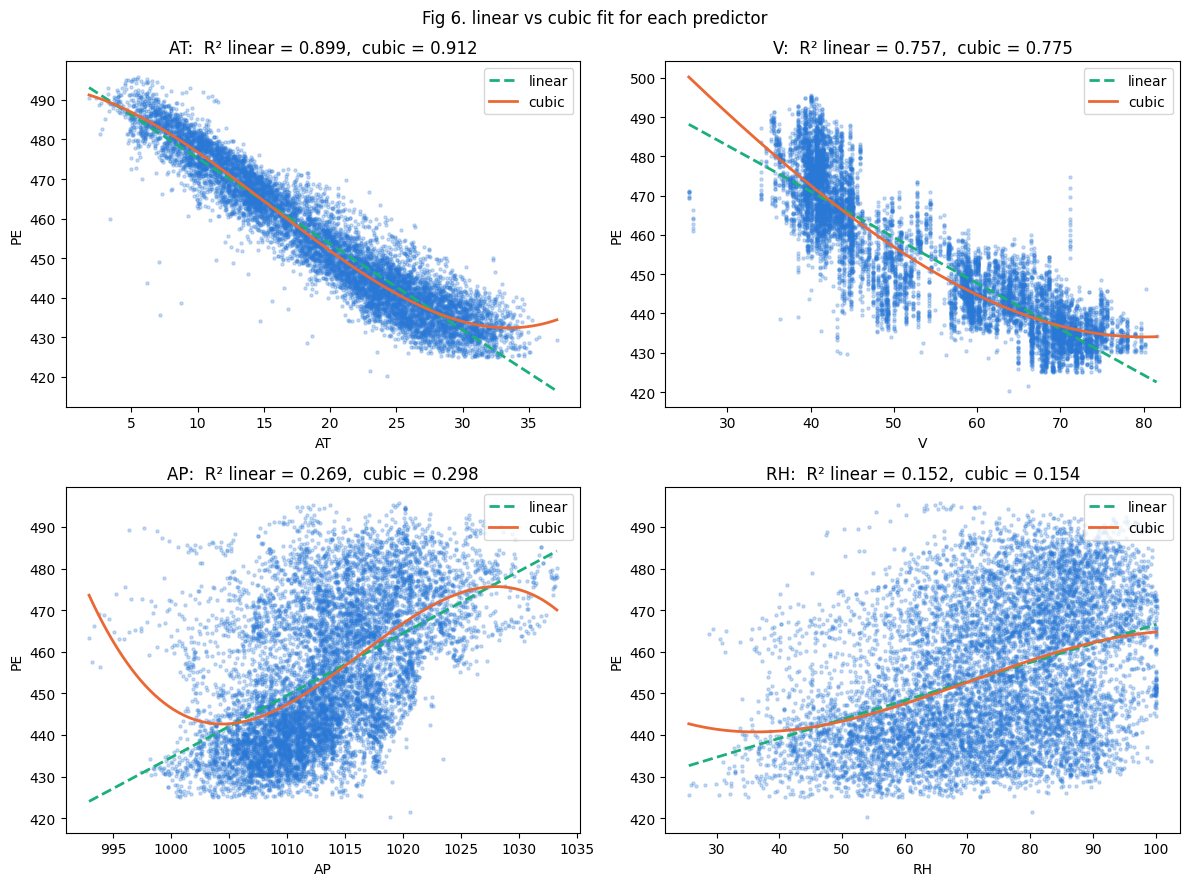

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i in range(len(predictors)):
    predictor = predictors[i]
    ax = axes[i]
    cubic_model = cubic_models[predictor]
    linear_model = simple_models[predictor]

    x_values = np.linspace(df[predictor].min(), df[predictor].max(), 200)
    z_values = (x_values - df[predictor].mean()) / df[predictor].std()
    z_column = z_values.reshape(-1, 1)
    polynomial_values = poly.transform(z_column)
    polynomial_values = sm.add_constant(polynomial_values)
    cubic_predictions = cubic_model.predict(polynomial_values)
    linear_predictions = linear_model.params["const"] + linear_model.params[predictor] * x_values

    ax.scatter(df[predictor], df[response], s=5, alpha=0.25, color=C_PTS)
    ax.plot(x_values, linear_predictions, color=C_ALT, lw=2, ls="--", label="linear")
    ax.plot(x_values, cubic_predictions, color=C_FIT, lw=2, label="cubic")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")
    ax.legend(loc="upper right")
    ax.set_title(f"{predictor}:  R² linear = {linear_model.rsquared:.3f},  cubic = {cubic_model.rsquared:.3f}")

fig.suptitle("Fig 6. linear vs cubic fit for each predictor")
fig.tight_layout()
plt.show()

The joint F-tests support a curved fit for all four predictors. AP gets the biggest R² jump, though AT + V still explain more of PE overall. RH barely improves, and its squared term alone isn't significant.

### 1(g) - Pairwise interactions

An interaction lets one predictor's effect depend on another. AT × V, for example, lets the AT slope change with V.

Standardizing the predictors, then fitting all four main effects + the six pairwise products with `PE ~ (AT + V + AP + RH)**2`. Keeping the main effects along with the interactions (Lesson 2, PDF pp. 98–111).

In [15]:
dfz = (df[predictors] - df[predictors].mean()) / df[predictors].std()
dfz[response] = df[response].values
inter_model = smf.ols("PE ~ (AT + V + AP + RH)**2", data=dfz).fit()
print(inter_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:57:33   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.6946      0.075   6074.393      0.0

In [16]:
inter_terms = []
for term in inter_model.params.index:
    if ":" in term:
        inter_terms.append(term)
inter_tbl = pd.DataFrame({"coef": inter_model.params[inter_terms],
                          "p-value": inter_model.pvalues[inter_terms],
                          "significant at 0.05": inter_model.pvalues[inter_terms] < 0.05})
print("R² main effects only:", round(mlr.rsquared, 4), "  with interactions:", round(inter_model.rsquared, 4))
inter_tbl

R² main effects only: 0.9287   with interactions: 0.9363


,coef,p-value,significant at 0.05
AT:V,1.986,3.333e-117,True
AT:AP,0.07785,0.4521,False
AT:RH,-0.5691,1.217e-10,True
V:AP,0.5141,2.877e-07,True
V:RH,0.1556,0.08619,False
AP:RH,-0.1398,0.03361,True


AT:V, AT:RH, V:AP, and AP:RH are significant at α = 0.05. AT:AP + V:RH aren't. All four main effects stay significant.

R² goes from 0.9287 to 0.9363, so the interactions help a little.

### 1(h) - Do interactions / nonlinearities help?

70/30 train/test split with a fixed seed, reusing the same split for KNN. Standardizing with the training mean + standard deviation.

- **Model A:** the four predictors only.
- **Model B full:** add six interactions + four squared terms.
- **Model B pruned:** drop the largest p-value above 0.05, refit, repeat. Keep a main effect if an interaction or square still uses it.

The dropping rule follows Lesson 2's backward selection procedure (PDF pp. 85–86). Keeping main effects with their interactions follows pp. 110–111; doing the same for squares here. Lesson 5 also covers backward selection (pp. 20–23), using model fit to compare removals.

Comparing train + test MSE below. Lower is better; taking the square root gives RMSE in MW.

In [17]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=SEED)
training_mean = train_df[predictors].mean()
training_sd = train_df[predictors].std()

def zscore(data):
    standardized = (data[predictors] - training_mean) / training_sd
    standardized[response] = data[response].values
    return standardized

train_z = zscore(train_df)
test_z = zscore(test_df)
print("train:", train_z.shape, " test:", test_z.shape)

# Match on all columns, including PE, to find identical observations.
unique_test_rows = test_df.drop_duplicates()
all_columns = list(df.columns)
shared_rows = train_df.merge(unique_test_rows, on=all_columns, how="inner")
print("training rows with an identical test counterpart:", len(shared_rows))

def mse(model, data):
    predictions = model.predict(data)
    error = mean_squared_error(data[response], predictions)
    return error

train: (6697, 5)  test: (2871, 5)
training rows with an identical test counterpart: 15


In [18]:
main_terms = list(predictors)
inter_terms_all = []
quad_terms = []
term_predictors = {}

# Store which predictors belong to each term so hierarchy checks are explicit.
for predictor in predictors:
    term_predictors[predictor] = [predictor]

# Start j after i to create each pair once (AT:V, but not also V:AT).
for i in range(len(predictors)):
    for j in range(i + 1, len(predictors)):
        first = predictors[i]
        second = predictors[j]
        term = f"{first}:{second}"
        inter_terms_all.append(term)
        term_predictors[term] = [first, second]

for predictor in predictors:
    # I(...) tells the formula interface to calculate the square directly.
    term = f"I({predictor} ** 2)"
    quad_terms.append(term)
    term_predictors[term] = [predictor]

full_terms = main_terms + inter_terms_all + quad_terms
higher_order_terms = inter_terms_all + quad_terms

def fit_terms(terms, data):
    formula = "PE ~ " + " + ".join(terms)
    model = smf.ols(formula, data=data).fit()
    return model

def backward_eliminate(starting_terms, data, alpha=0.05):
    terms = list(starting_terms)
    dropped = []

    while True:
        model = fit_terms(terms, data)

        # Keep a main effect if a retained interaction or square uses it.
        protected_predictors = []
        for term in terms:
            if term in higher_order_terms:
                for predictor in term_predictors[term]:
                    if predictor not in protected_predictors:
                        protected_predictors.append(predictor)

        # Find the largest p-value among terms that can be removed.
        worst_term = None
        worst_p_value = alpha
        for term in terms:
            if term in main_terms and term in protected_predictors:
                continue
            p_value = model.pvalues[term]
            if p_value > worst_p_value:
                worst_term = term
                worst_p_value = p_value

        # Stop when no eligible term has a p-value above alpha.
        if worst_term is None:
            return model, terms, dropped

        dropped.append((worst_term, worst_p_value))
        terms.remove(worst_term)

model_A = fit_terms(main_terms, train_z)
model_B_full = fit_terms(full_terms, train_z)
model_B, kept_terms, dropped = backward_eliminate(full_terms, train_z)

print("dropped in order (term, p-value at removal):")
for term, p_value in dropped:
    print(f"   {term:14s} p = {p_value:.3f}")
print("\nkept:", kept_terms)

dropped in order (term, p-value at removal):
   AT:AP          p = 0.492
   V:RH           p = 0.379
   I(V ** 2)      p = 0.093

kept: ['AT', 'V', 'AP', 'RH', 'AT:V', 'AT:RH', 'V:AP', 'AP:RH', 'I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)']


In [19]:
pd.DataFrame({"coef": model_B.params, "p-value": model_B.pvalues})

,coef,p-value
Intercept,453.2,0
AT,-13.44,0
V,-3.768,1.16e-230
AP,0.7948,1.382e-30
RH,-1.78,6.947e-123
AT:V,0.7922,3.548e-08
AT:RH,-0.4814,1.85e-06
V:AP,0.3164,9.527e-05
AP:RH,-0.3299,1.667e-06
I(AT ** 2),1.147,8.212e-20


In [20]:
regression_models = [model_A, model_B_full, model_B]
model_names = [
    "A: linear, 4 predictors",
    "B full: + interactions + quadratics",
    "B pruned: p-value backward elimination",
]
term_counts = [len(main_terms), len(full_terms), len(kept_terms)]
rows = []

for i in range(len(regression_models)):
    model = regression_models[i]
    row = {
        "terms": term_counts[i],
        "train MSE": mse(model, train_z),
        "test MSE": mse(model, test_z),
        "train R²": model.rsquared,
    }
    rows.append(row)

results_h = pd.DataFrame(rows, index=model_names)

def format_mse(value):
    return f"{value:.4f}"

with pd.option_context("display.float_format", format_mse):
    display(results_h)

,terms,train MSE,test MSE,train R²
"A: linear, 4 predictors",4,20.3547,21.7414,0.9302
B full: + interactions + quadratics,14,17.6979,19.0818,0.9393
B pruned: p-value backward elimination,11,17.7087,19.0829,0.9393


6,697 training rows + 2,871 test rows. Adding interactions and squares drops test MSE from 21.7414 to 19.0818, about 12% better. RMSE goes from 4.66 to 4.37 MW.

Backward selection drops AT:AP, V:RH, and V². Test MSE barely changes, ending at 19.0829. I'd take the pruned model since it gives almost the same error with three fewer terms. Part (j) still uses the full model as the numerical winner, since its test MSE is slightly lower.

There are also 15 training rows with identical test counterparts. That overlap may make the test errors look a little better.

### 1(i) - KNN regression

KNN averages the outputs of the k closest training points. Small k keeps it local, large k averages over more points (Lesson 1, PDF p. 90).

Same split as (h), sweeping k = 1..100 for raw + standardized features. `StandardScaler` fits on train, then transforms both sets. Plotting against 1/k, so small k is on the right.

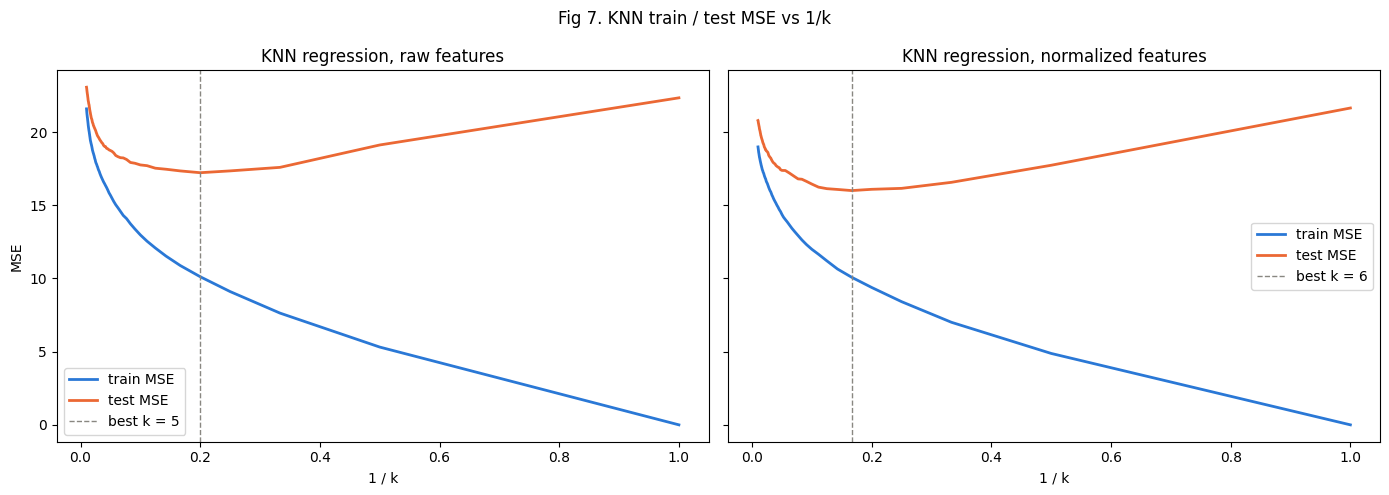

,best k,train MSE at best k,test MSE at best k
raw,5,10.12,17.22
normalized,6,10.08,16


In [21]:
X_train_raw = train_df[predictors].values
X_test_raw = test_df[predictors].values
y_train = train_df[response].values
y_test = test_df[response].values

scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train_z = scaler.transform(X_train_raw)
X_test_z = scaler.transform(X_test_raw)
ks = np.arange(1, 101)

def knn_sweep(X_train, X_test, y_train, y_test):
    train_errors = []
    test_errors = []

    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train, y_train)
        train_predictions = knn.predict(X_train)
        test_predictions = knn.predict(X_test)
        train_error = mean_squared_error(y_train, train_predictions)
        test_error = mean_squared_error(y_test, test_predictions)
        train_errors.append(train_error)
        test_errors.append(test_error)

    return np.array(train_errors), np.array(test_errors)

tr_raw, te_raw = knn_sweep(X_train_raw, X_test_raw, y_train, y_test)
tr_z, te_z = knn_sweep(X_train_z, X_test_z, y_train, y_test)

best_raw_index = np.argmin(te_raw)
best_z_index = np.argmin(te_z)
best_raw_k = ks[best_raw_index]
best_z_k = ks[best_z_index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
feature_names = ["raw features", "normalized features"]
training_curves = [tr_raw, tr_z]
testing_curves = [te_raw, te_z]
best_k_values = [best_raw_k, best_z_k]

for i in range(len(feature_names)):
    ax = axes[i]
    name = feature_names[i]
    best_k = best_k_values[i]
    ax.plot(1 / ks, training_curves[i], color=C_PTS, lw=2, label="train MSE")
    ax.plot(1 / ks, testing_curves[i], color=C_FIT, lw=2, label="test MSE")
    ax.axvline(1 / best_k, color=C_REF, ls="--", lw=1, label=f"best k = {best_k}")
    ax.set_xlabel("1 / k")
    ax.set_title(f"KNN regression, {name}")
    ax.legend()

axes[0].set_ylabel("MSE")
fig.suptitle("Fig 7. KNN train / test MSE vs 1/k")
fig.tight_layout()
plt.show()

knn_best = pd.DataFrame({
    "best k": [best_raw_k, best_z_k],
    "train MSE at best k": [tr_raw[best_raw_index], tr_z[best_z_index]],
    "test MSE at best k": [te_raw[best_raw_index], te_z[best_z_index]],
}, index=["raw", "normalized"])
knn_best

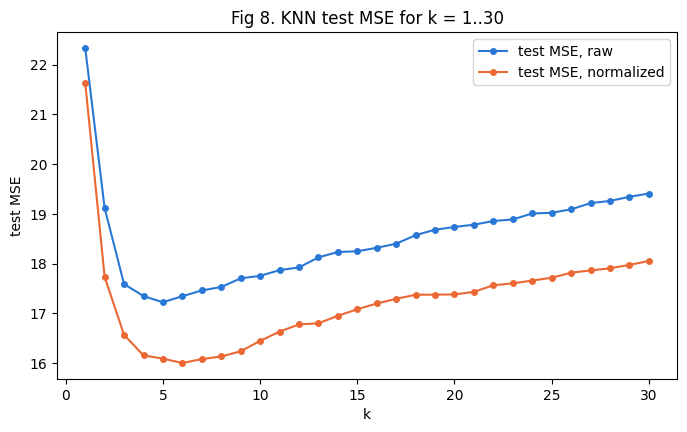

In [ ]:
# zoom into the minimum 

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ks[:30], te_raw[:30], marker="o", ms=4, color=C_PTS, lw=1.5, label="test MSE, raw")
ax.plot(ks[:30], te_z[:30], marker="o", ms=4, color=C_FIT, lw=1.5, label="test MSE, normalized")
ax.set_xlabel("k")
ax.set_ylabel("test MSE")
ax.legend()
ax.set_title("Fig 8. KNN test MSE for k = 1..30")
plt.show()

Best test error is at k = 5 for raw features and k = 6 for standardized features. Standardizing gives lower test error at every k tested.

At very small k, train error is low but test error goes back up. The closest point alone seems too sensitive to local variation. Scaling helps because a feature's units otherwise affect how much it counts in the distance.

### 1(j) - KNN vs best linear model

Using the lowest test MSE to pick the regression model here: full interactions + quadratics. The pruned model from (h) is almost tied, with fewer terms.

In [23]:
# Select the regression model with the lowest test MSE.
best_lin_name = results_h["test MSE"].idxmin()
best_linear_result = results_h.loc[best_lin_name]
raw_knn_result = knn_best.loc["raw"]
normalized_knn_result = knn_best.loc["normalized"]

training_errors = [
    best_linear_result["train MSE"],
    raw_knn_result["train MSE at best k"],
    normalized_knn_result["train MSE at best k"],
]
testing_errors = [
    best_linear_result["test MSE"],
    raw_knn_result["test MSE at best k"],
    normalized_knn_result["test MSE at best k"],
]
comparison_names = [
    f"linear: {best_lin_name}",
    f"KNN raw (k={best_raw_k})",
    f"KNN normalized (k={best_z_k})",
]

compare = pd.DataFrame({
    "train MSE": training_errors,
    "test MSE": testing_errors,
}, index=comparison_names)
compare["test RMSE (MW)"] = np.sqrt(compare["test MSE"])
compare

,train MSE,test MSE,test RMSE (MW)
linear: B full: + interactions + quadratics,17.7,19.08,4.368
KNN raw (k=5),10.12,17.22,4.15
KNN normalized (k=6),10.08,16,4


Standardized KNN comes out best on this split, with test MSE around 16 vs 19.08 for the full regression model. About a 16% drop. Averaging nearby points seems to pick up patterns the regression misses.

I picked k using these same test errors though, so this isn't a fresh test of the chosen KNN. Lesson 4 separates model selection from final testing. A next step would be cross-validation on the training set to choose k (Lessons 4 + 5), and keeping duplicate rows together when splitting.

I'd choose standardized KNN for prediction from these results. If I needed an equation that's easier to explain, I'd use the pruned regression.

## 2. ISLR 2.4.1

Flexible vs inflexible methods:

### (a) n extremely large, p small

Flexible generally does better. Lots of data relative to the number of predictors, so there's more room to fit a detailed pattern without fitting too much noise.

### (b) p extremely large, n small

Inflexible generally does better. Too many predictors and not much data; a flexible model can fit the noise pretty easily.`

### (c) relationship highly nonlinear

Flexible generally does better. It can follow the bends that a simpler model would miss.

### (d) Var(ε) = σ² is extremely high

Inflexible generally does better. With this much noise, extra flexibility can end up chasing it. Neither method can remove the noise itself.

## 3. ISLR 2.4.7

Training points from the textbook table: 3 predictors + a class label. Test point is (0, 0, 0).

### (a) Euclidean distances

In [24]:
obs = pd.DataFrame({"X1": [0, 2, 0, 0, -1, 1],
                    "X2": [3, 0, 1, 1, 0, 1],
                    "X3": [0, 0, 3, 2, 1, 1],
                    "Y":  ["Red", "Red", "Red", "Green", "Green", "Red"]},
                   index=pd.Index(range(1, 7), name="Obs"))
squared_distances = obs["X1"] ** 2 + obs["X2"] ** 2 + obs["X3"] ** 2
obs["distance"] = np.sqrt(squared_distances)
obs["distance (exact)"] = ["√9 = 3", "√4 = 2", "√10", "√5", "√2", "√3"]
obs.sort_values("distance")

,X1,X2,X3,Y,distance,distance (exact)
Obs,,,,,,
5,-1,0,1,Green,1.414,√2
6,1,1,1,Red,1.732,√3
2,2,0,0,Red,2,√4 = 2
4,0,1,2,Green,2.236,√5
1,0,3,0,Red,3,√9 = 3
3,0,1,3,Red,3.162,√10


Distances for observations 1-6: 3, 2, √10, √5, √2, √3.

### (b) K = 1

Green, observation 5 is closest, at √2.

### (c) K = 3

Red, nearest three are 5 (Green), 6 (Red), and 2 (Red), so Red wins 2-to-1.

### (d) Highly nonlinear Bayes decision boundary

Small K since it gives a more flexible boundary that can follow the nonlinear pattern. Large K smooths out more of those bends.

### References

- UCI Combined Cycle Power Plant dataset and the accompanying `data/CCPP/Readme.txt`: https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant. The readme identifies the dataset papers by Tüfekci (2014) and Kaya et al. (2012).
- James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning*, chapter 2 (bias, variance, and KNN) and chapter 3 (linear regression, interactions, hierarchy, and diagnostics).
Course slides reviewed through Lesson 5 (page numbers refer to PDF pages):

- Lesson 1: Introduction, pp. 59 and 90: neighbor averaging and the choice of k.
- Lesson 2: Linear Regression, pp. 35–37: slope tests; pp. 85–86: p-value backward selection; pp. 98–111: interactions and hierarchy; p. 115: polynomial fits; p. 117: topics not covered.
- Lesson 3: Classification, reviewed for classification context; the regression analysis above mainly uses Lessons 1 and 2.
- Lesson 4: Resampling, pp. 10–11: training, validation, and test roles; pp. 23–31: k-fold cross-validation.
- Lesson 5: Model Selection, pp. 20–23: backward stepwise selection; pp. 38–41: validation and cross-validation for model choice.

AI tools also helped revise the explanations and check their connection to these slides. The additional residual diagnostics are disclosed in section 1(c).

API references checked for the notebook:

- statsmodels [OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html) and [formula-based OLS](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html).
- statsmodels [OLSInfluence](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html).
- scikit-learn [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html), [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html), [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), and [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).